In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import gc
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import optuna
import xgboost as xgb
from statsmodels.tsa.seasonal import seasonal_decompose

optuna.logging.set_verbosity(optuna.logging.INFO)
sns.set_theme(style="whitegrid")

In [2]:
# https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data

# 1. Read the data

In [3]:
train = pd.read_csv("train.csv", parse_dates=["date"])
test = pd.read_csv("test.csv", parse_dates=["date"])
stores = pd.read_csv("stores.csv")
oil = pd.read_csv("oil.csv", parse_dates=["date"])
holidays = pd.read_csv("holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv("transactions.csv", parse_dates=["date"])  # EDA only

# Tag rows so train and test can be feature-engineered together, then easily split apart again
train["is_test"] = False
test["is_test"] = True
test["sales"] = np.nan

df = pd.concat([train, test], ignore_index=True).sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

In [4]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,is_test
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,False
1,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,False
2,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,False
3,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,False
4,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,False


# 2. Data wrangling

In [5]:
df.dtypes

id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
is_test                  bool
dtype: object

In [6]:
df.isna().sum()[df.isna().sum() > 0]  # sales will show around 28.5k NaNs, exactly the test rows, which is expected

sales    28512
dtype: int64

In [7]:
df = df.merge(stores, on="store_nbr", how="left")
df["onpromotion"] = df["onpromotion"].astype("int16")

In [8]:
# Oil is only reported on trading days, so most calendar dates are missing entirely. Reindex to every calendar day first, then interpolate, otherwise weekend/holiday rows would stay empty after the merge.
full_dates = pd.DataFrame({"date": pd.date_range(oil["date"].min(), oil["date"].max())})
oil_full = full_dates.merge(oil, on="date", how="left")
oil_full["dcoilwtico"] = oil_full["dcoilwtico"].interpolate().bfill().astype("float32")  # bfill covers day 1, which has nothing before it to interpolate from

df = df.merge(oil_full, on="date", how="left")

In [9]:
# transferred == True rows are holidays that were not observed on that date, count only the rest.
hol = holidays[holidays["transferred"] == False].copy()

national = hol[hol["locale"] == "National"][["date"]].drop_duplicates().assign(is_holiday_national=1)
regional = (hol[hol["locale"] == "Regional"][["date", "locale_name"]]
            .rename(columns={"locale_name": "state"}).drop_duplicates().assign(is_holiday_regional=1))
local = (hol[hol["locale"] == "Local"][["date", "locale_name"]]
         .rename(columns={"locale_name": "city"}).drop_duplicates().assign(is_holiday_local=1))

df = df.merge(national, on="date", how="left")
df = df.merge(regional, on=["date", "state"], how="left")
df = df.merge(local, on=["date", "city"], how="left")

for c in ["is_holiday_national", "is_holiday_regional", "is_holiday_local"]:
    df[c] = df[c].fillna(0).astype("int8")

df["is_holiday"] = df[["is_holiday_national", "is_holiday_regional", "is_holiday_local"]].max(axis=1).astype("int8")
df["store_nbr"] = df["store_nbr"].astype("int8")
df["cluster"] = df["cluster"].astype("int8")

# city/state were only needed as merge keys above, cluster + type already capture most of the store-segmentation signal they'd add, and both are high-cardinality (22 cities, 16 states) -> they're dropped rather than one-hot-encoded.
df = df.drop(columns=["city", "state"])

This is a simplified treatment: it ignores the Bridge/Work Day/Additional event subtypes and doesn't reconstruct where a transferred holiday actually landed. A more rigorous version would model each event subtype as its own flag.

In [10]:
df.dtypes

id                              int64
date                   datetime64[ns]
store_nbr                        int8
family                         object
sales                         float64
onpromotion                     int16
is_test                          bool
type                           object
cluster                          int8
dcoilwtico                    float32
is_holiday_national              int8
is_holiday_regional              int8
is_holiday_local                 int8
is_holiday                       int8
dtype: object

In [11]:
df["year"] = df["date"].dt.year.astype("int16")
df["month"] = df["date"].dt.month.astype("int8")
df["day"] = df["date"].dt.day.astype("int8")
df["dayofweek"] = df["date"].dt.dayofweek.astype("int8")
df["dayofyear"] = df["date"].dt.dayofyear.astype("int16")
df["weekofyear"] = df["date"].dt.isocalendar().week.astype("int8")
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype("int8")
df["is_month_start"] = df["date"].dt.is_month_start.astype("int8")
df["is_month_end"] = df["date"].dt.is_month_end.astype("int8")
df["days_since_start"] = (df["date"] - df["date"].min()).dt.days.astype("int32")  # linear trend term

In [12]:
HORIZON = 16  # length of test.csv's date range (Aug 16-31, 2017), the minimum safe lag

df = df.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)
grp = df.groupby(["store_nbr", "family"])["sales"]

# Lag features. Every lag >= HORIZON days back as this keeps every test row fillable from real history without a recursive/iterative forecasting loop
for lag in [16, 21, 28, 35, 365]:
    df[f"sales_lag_{lag}"] = grp.shift(lag).astype("float32")

# Rolling mean and std features, anchored HORIZON days back for the same reason.
for window in [7, 14, 28]:
    df[f"sales_roll_mean_{window}"] = grp.transform(lambda s: s.shift(HORIZON).rolling(window).mean()).astype("float32")
    df[f"sales_roll_std_{window}"] = grp.transform(lambda s: s.shift(HORIZON).rolling(window).std()).astype("float32")

# Promotion lag. Onpromotion is already known for the real test dates, but recent promo momentum for the same store/family is still informative
df["onpromotion_lag_16"] = df.groupby(["store_nbr", "family"])["onpromotion"].shift(16).astype("float32")

lag_roll_cols = [c for c in df.columns if c.startswith("sales_lag_") or c.startswith("sales_roll_")]

In [13]:
# Keep the pre-encoding family/type labels for EDA plots, before they get one-hot encoded for modeling below
family_labels = df["family"].copy()
type_labels = df["type"].copy()

categorical_cols = ["family", "type"]  # 33 product families, 5 store types (A-E)
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [14]:
df.dtypes

id                         int64
date              datetime64[ns]
store_nbr                   int8
sales                    float64
onpromotion                int16
                       ...      
family_SEAFOOD              bool
type_B                      bool
type_C                      bool
type_D                      bool
type_E                      bool
Length: 70, dtype: object

# 3. Exploratory Data Analysis

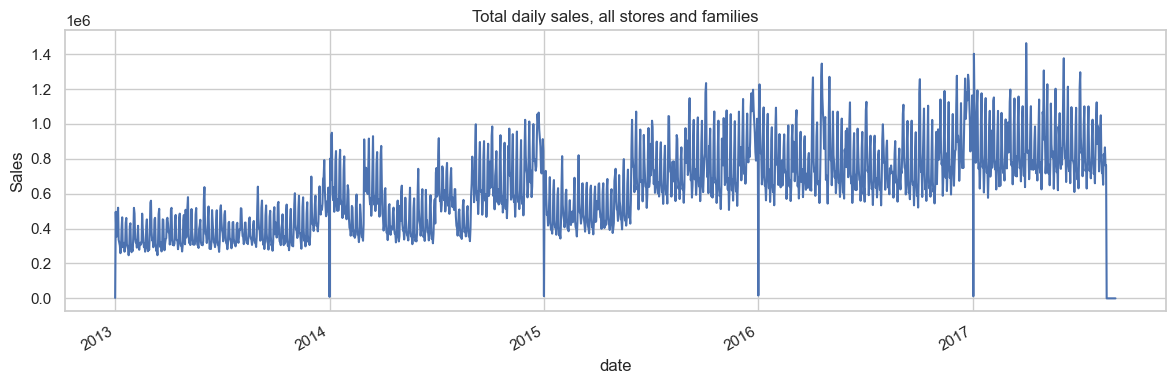

In [15]:
df.groupby("date")["sales"].sum().plot(figsize=(12, 4), title="Total daily sales, all stores and families")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

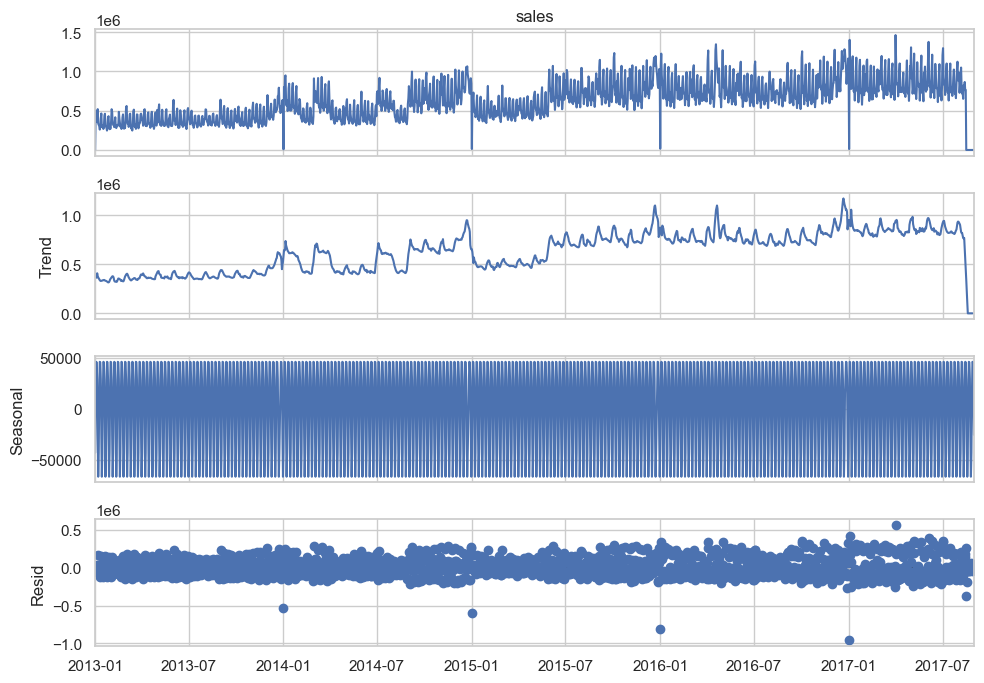

In [16]:
result = seasonal_decompose(df.groupby("date")["sales"].sum(), period=7)
fig = result.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

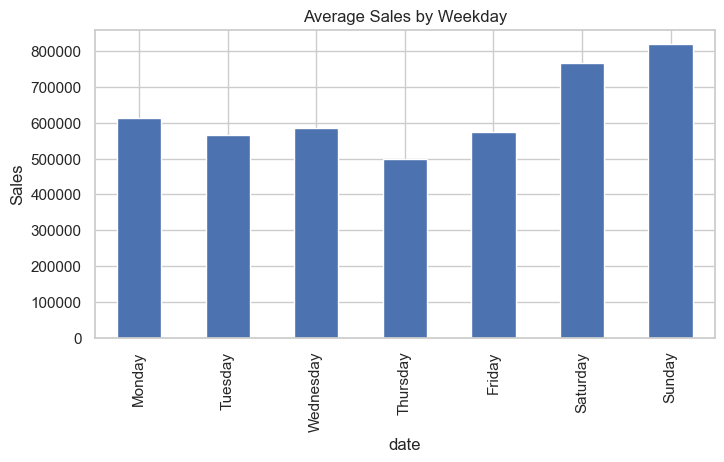

In [17]:
daily = df.groupby("date")["sales"].sum()

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = daily.groupby(daily.index.day_name()).mean().reindex(days)

weekday_avg.plot.bar(figsize=(8, 4), title="Average Sales by Weekday", ylabel="Sales")
plt.show()

The decomposition indicates a weekly seasonal pattern and substantial long-term sales growth from 2013 to 2017, while the large residuals suggest that holidays, promotions, and other factors explain a significant share of the remaining variation.

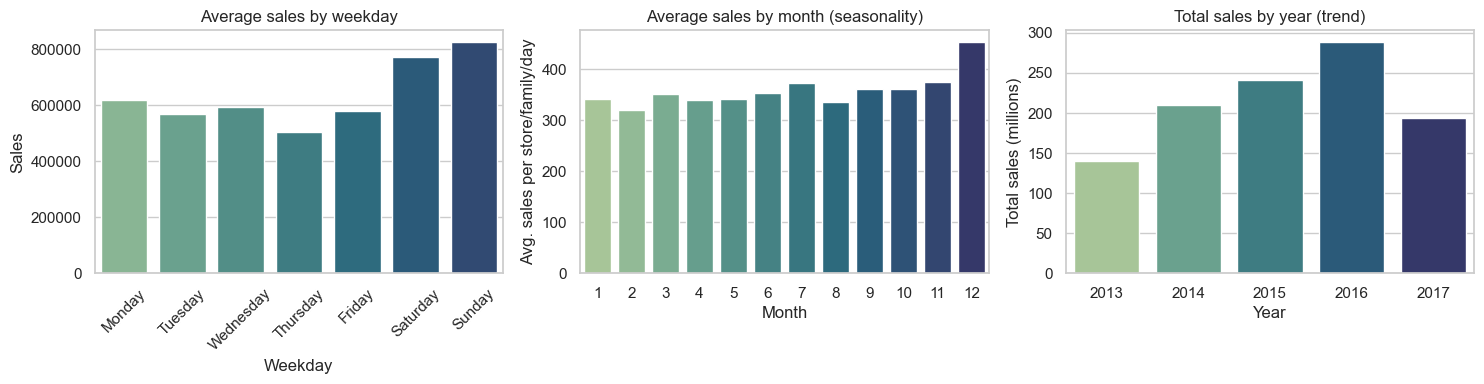

In [18]:
daily = df.loc[df["is_test"] == False].groupby("date")["sales"].sum()
monthly = df.loc[df["is_test"] == False].groupby("month")["sales"].mean()
yearly = df.loc[df["is_test"] == False].groupby("year")["sales"].sum()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_avg = daily.groupby(daily.index.day_name()).mean().reindex(days)
sns.barplot(x=weekday_avg.index, y=weekday_avg.values, ax=axes[0], hue=weekday_avg.index, palette="crest", legend=False)
axes[0].set_title("Average sales by weekday")
axes[0].set_xlabel("Weekday")
axes[0].set_ylabel("Sales")
axes[0].tick_params(axis="x", labelrotation=45)

sns.barplot(x=monthly.index, y=monthly.values, ax=axes[1], hue=monthly.index, palette="crest", legend=False)
axes[1].set_title("Average sales by month (seasonality)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg. sales per store/family/day")

sns.barplot(x=yearly.index, y=yearly.values / 1e6, ax=axes[2], hue=yearly.index, palette="crest", legend=False)
axes[2].set_title("Total sales by year (trend)")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Total sales (millions)")
plt.tight_layout()
plt.show()

**December** sales are clearly higher on average than **February**, the month with the lowest average sales. The year-over-year totals show a steady growth trend (2013 to 2016 total sales roughly doubled), with 2017 looking lower because the data stops in August.

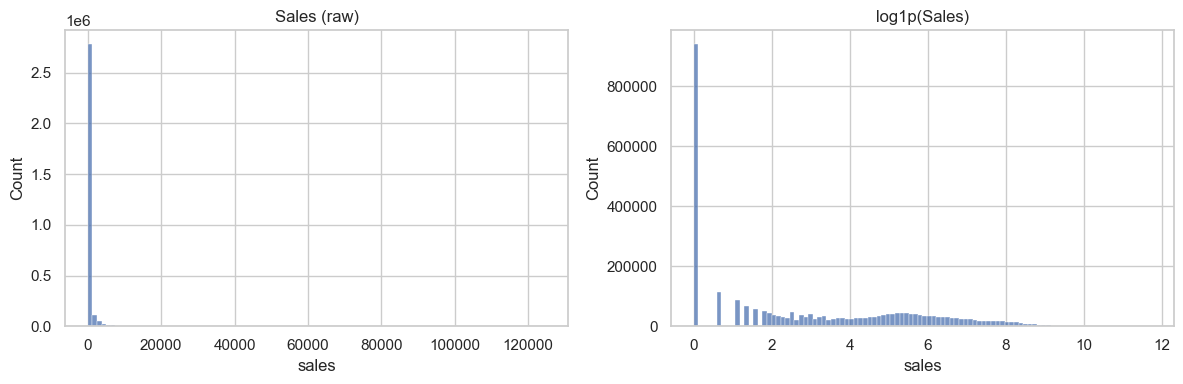

In [19]:
train_sales = df.loc[df["is_test"] == False, "sales"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_sales, bins=100, ax=axes[0])
axes[0].set_title("Sales (raw)")
sns.histplot(np.log1p(train_sales), bins=100, ax=axes[1])
axes[1].set_title("log1p(Sales)")
plt.tight_layout()
plt.show()

Raw daily sales are heavily right-skewed; `log1p` compresses that down to a much lower skewness, so using `log1p(sales)` as the modeling target is warranted. The same right-skew rationale the insurance notebook used for `Premium`.

In [20]:
# Correlate sales against the engineered features. corr() over the full 3M-row frame is memory-heavy, so a large random sample is used instead
numeric_df = df.select_dtypes(include=["number", "bool"]).drop(columns=["id"])
bool_cols = numeric_df.select_dtypes(include="bool").columns
numeric_df[bool_cols] = numeric_df[bool_cols].astype("int8")

corr_sample = numeric_df.sample(n=300_000, random_state=0)
corr_data = corr_sample.corr()["sales"].drop("sales").sort_values(ascending=False)
corr_data

sales_roll_mean_28    0.908149
sales_roll_mean_14    0.907358
sales_lag_28          0.907000
sales_roll_mean_7     0.906171
sales_lag_21          0.905501
                        ...   
family_BEAUTY        -0.057406
family_BOOKS         -0.057436
dcoilwtico           -0.073468
type_C               -0.089179
is_test                    NaN
Name: sales, Length: 67, dtype: float64

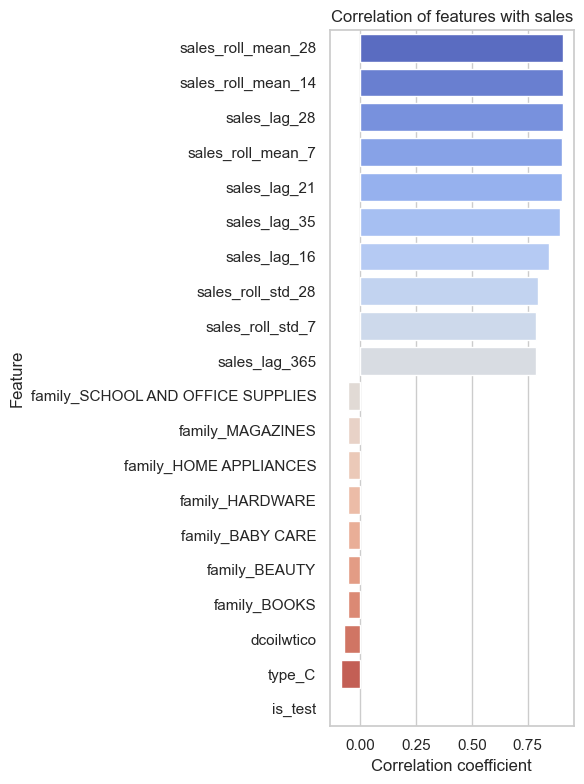

In [21]:
# Visualization of correlations (top and bottom features by magnitude)
top_bottom = pd.concat([corr_data.head(10), corr_data.tail(10)])

plt.subplots(figsize=(6, 8))
sns.barplot(x=top_bottom.values, y=top_bottom.index, hue=top_bottom.index, palette="coolwarm", legend=False)
plt.title("Correlation of features with sales")
plt.xlabel("Correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

As expected, the strongest correlates of `sales` are its own recent history. Further down, `dcoilwtico` and `type_C` show mild negative correlations.

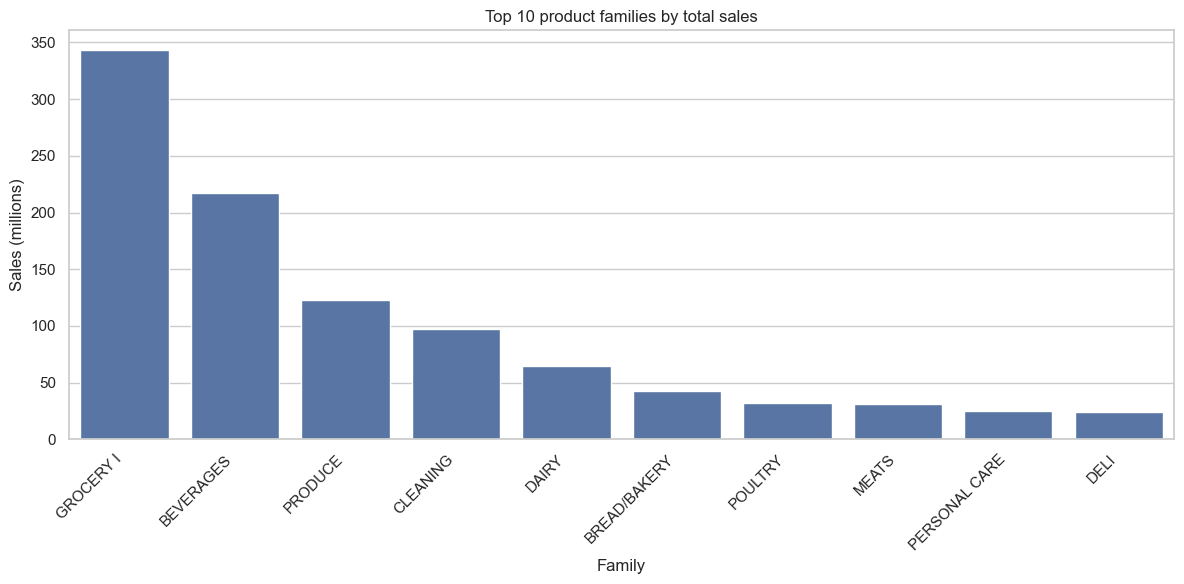

In [22]:
tmp = pd.DataFrame({"family": family_labels, "sales": df["sales"]})
family_sales = tmp.groupby("family")["sales"].sum().sort_values(ascending=False)

top10 = (family_sales.head(10) / 1e6).reset_index()
top10.columns = ["family", "sales_m"]

plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="family", y="sales_m")
plt.ylabel("Sales (millions)")
plt.xlabel("Family")
plt.title("Top 10 product families by total sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The distribution within the top 10 product categories is not even. **GROCERY I** is clearly the largest product family, and it outsells the next best-selling family **BEVERAGES** by a wide margin. This visualization demonstrates why `family` is important to include in the model.

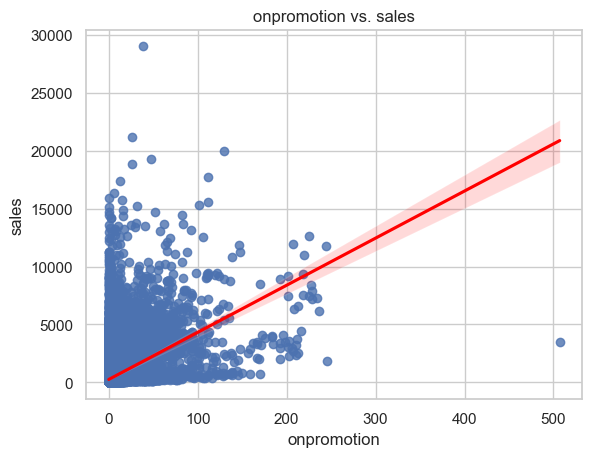

In [23]:
sns.regplot(x="onpromotion", y="sales", data=df.sample(50_000, random_state=0), line_kws={"color": "red"})
plt.title("onpromotion vs. sales")
plt.show()

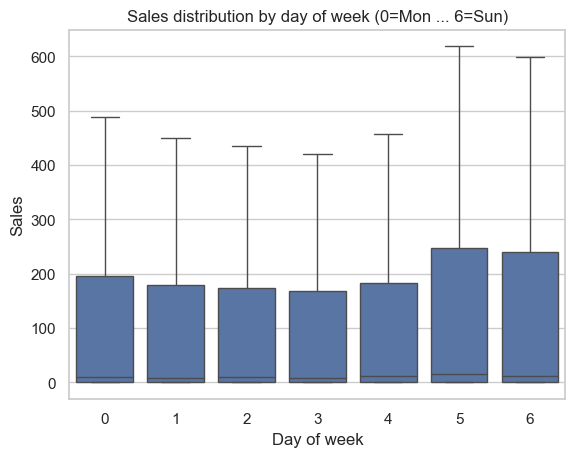

In [24]:
sns.boxplot(x="dayofweek", y="sales", data=df, showfliers=False)
plt.title("Sales distribution by day of week (0=Mon ... 6=Sun)")
plt.xlabel("Day of week")
plt.ylabel("Sales")
plt.show()

Weekend sales run noticeably higher than weekday sales. The `dayofweek`/`is_weekend` calendar features and the 7-day rolling window are there to capture this variation in sales.

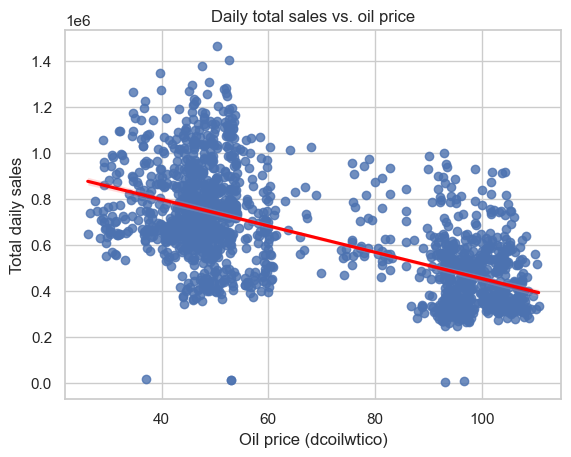

,sales,oil
sales,1.000000,-0.627999
oil,-0.627999,1.000000


In [25]:
daily = (df[df["is_test"] == False]
         .groupby("date")
         .agg(sales=("sales", "sum"), oil=("dcoilwtico", "mean"), is_holiday=("is_holiday", "max"))
         .reset_index())

sns.regplot(x="oil", y="sales", data=daily, line_kws={"color": "red"})
plt.title("Daily total sales vs. oil price")
plt.xlabel("Oil price (dcoilwtico)")
plt.ylabel("Total daily sales")
plt.show()

daily[["sales", "oil"]].corr()

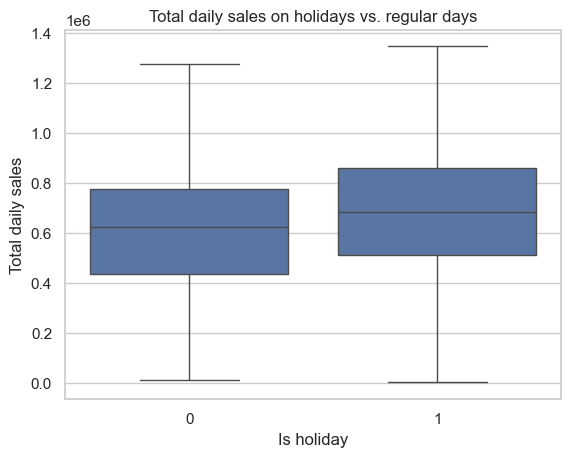

In [26]:
sns.boxplot(x="is_holiday", y="sales", data=daily, showfliers=False)
plt.title("Total daily sales on holidays vs. regular days")
plt.xlabel("Is holiday")
plt.ylabel("Total daily sales")
plt.show()

<Axes: xlabel='date', ylabel='sales'>

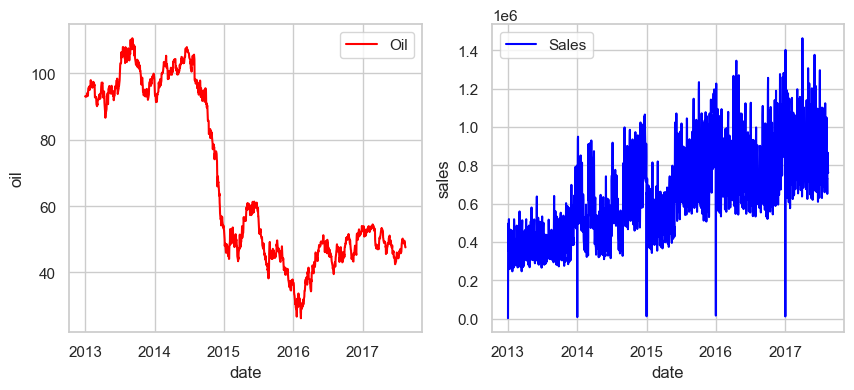

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.lineplot(x=daily["date"], y=daily["oil"], color="red", label="Oil", ax=axes[0])
sns.lineplot(x=daily["date"], y=daily["sales"], color="blue", label="Sales", ax=axes[1])

Daily sales and oil price show a moderate negative correlation of approximately -0.63. The relationship isn't direct, however since the daily sales have grown even when oil prices have fluctuated. National holidays show a clearer, more direct effect on median sales, which are higher on holidays.

# 4. Model development

In [28]:
# 4.1 Time-based train/validation split
#
# A random train_test_split (or a shuffled KFold, later) would scatter future rows into the
# training set and past rows into the "test" set, so the model would effectively be graded on
# interpolating dates it already partially saw. Instead we use a chronological cutoff that mirrors
# the real test.csv horizon (16 days), plus a recent rolling window of history rather than the
# full 4.5-year archive: retail seasonality and promo strategy drift over multi-year periods, a
# recent window keeps the model responsive to that drift, and it keeps the notebook fast to re-run.

# transactions.csv is deliberately excluded from the feature set: it stops exactly where train.csv
# stops and never covers the test period, so using it would be leakage of the same kind as the
# insurance notebook's claims-history columns.

TRAIN_WINDOW_DAYS = 365  # ~1 year of history feeding the model, kept tight for memory/runtime headroom
cols_to_drop = ["id", "date", "sales", "is_test", "transactions"]

max_train_date = df.loc[df["is_test"] == False, "date"].max()
window_cutoff = max_train_date - pd.Timedelta(days=TRAIN_WINDOW_DAYS)

full_train = df[(df["is_test"] == False) & (df["date"] >= window_cutoff)].copy()
full_train = full_train.dropna(subset=lag_roll_cols)  # drops rows too early in a series to have a full lag_365 etc.

cutoff_date = full_train["date"].max() - pd.Timedelta(days=HORIZON)
dates = full_train["date"]

X = full_train.drop(columns=[c for c in cols_to_drop if c in full_train.columns])
y = np.log1p(full_train["sales"])  # same right-skew rationale as Premium in the insurance notebook

train_mask = (dates <= cutoff_date).values
valid_mask = (dates > cutoff_date).values

X_train, y_train = X[train_mask].copy(), y[train_mask].copy()
X_valid, y_valid = X[valid_mask].copy(), y[valid_mask].copy()

test_rows = df[df["is_test"] == True].copy()
X_test = test_rows.drop(columns=[c for c in cols_to_drop if c in test_rows.columns])[X.columns]
test_ids = test_rows["id"].astype(int).values
test_dates = test_rows["date"].values

print(f"X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")

X_train: (621918, 66), X_valid: (28512, 66), X_test: (28512, 66)


In [29]:
def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, index=X.columns, name="MI Score")
    return mi_scores.sort_values(ascending=False)

# Continuous features, everything else (family/type dummies, calendar parts, cluster, holiday) treated as discrete.
continuous_features = ["onpromotion", "onpromotion_lag_16", "dcoilwtico", "days_since_start"] + lag_roll_cols

# get_dummies produces bool columns, and select_dtypes(include="number") silently excludes bool,
# that would drop every family/type dummy from the MI ranking entirely, so bool is included
# explicitly and cast to int for mutual_info_regression.
X_num = X_train.select_dtypes(include=["number", "bool"]).copy()
bool_cols = X_num.select_dtypes(include="bool").columns
X_num[bool_cols] = X_num[bool_cols].astype("int8")

sample_idx = X_num.sample(n=min(50_000, len(X_num)), random_state=0).index
mi_scores = make_mi_scores(
    X_num.loc[sample_idx],
    y_train.loc[sample_idx],
    [col not in continuous_features for col in X_num.columns],
)

In [30]:
mi_scores.head(20)

sales_roll_mean_28    1.569270
sales_roll_mean_14    1.561996
sales_roll_mean_7     1.544487
sales_lag_28          1.519504
sales_lag_21          1.496897
sales_lag_35          1.469115
sales_lag_16          1.300264
sales_roll_std_28     1.299415
sales_roll_std_14     1.274853
sales_lag_365         1.248680
sales_roll_std_7      1.221325
onpromotion           0.493680
onpromotion_lag_16    0.434018
store_nbr             0.117970
family_GROCERY I      0.079740
cluster               0.076683
family_BEVERAGES      0.065810
family_CLEANING       0.048684
family_BABY CARE      0.046446
family_BOOKS          0.044028
Name: MI Score, dtype: float64

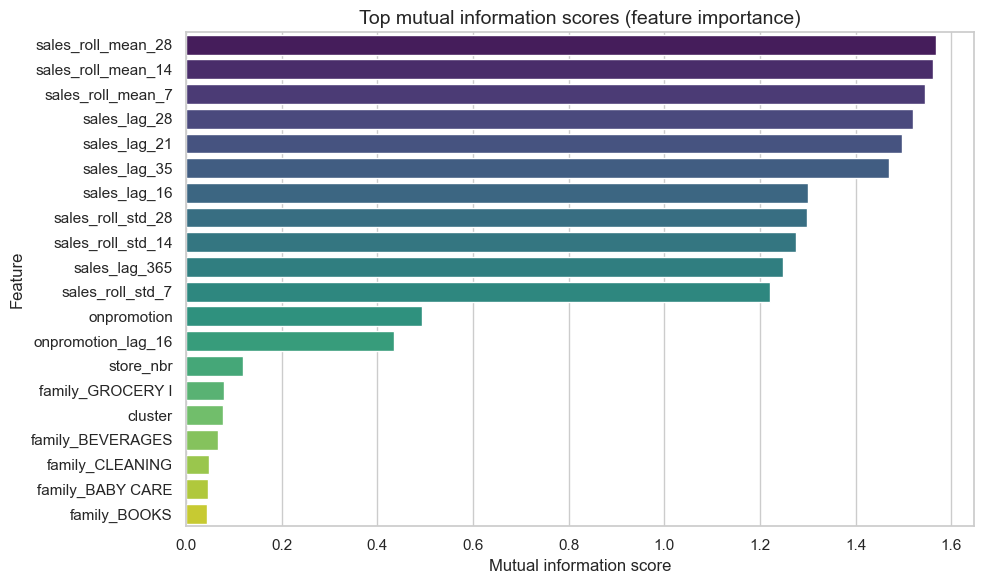

In [31]:
top_n = 20
plot_data = mi_scores.head(top_n).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=plot_data.values, y=plot_data.index, hue=plot_data.index, palette="viridis", legend=False)
plt.title("Top mutual information scores (feature importance)", fontsize=14)
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Mutual information tells the same story as the correlation analysis. The rolling-mean and lag sales features dominate the top of the ranking (MI scores of roughly 1.2-1.6), `onpromotion` and its 16-day lag are clearly less important, and `store_nbr`, the `family` dummies, and `cluster` contribute smaller but non-negligible signal. This is a reassuring sanity check before Optuna trials tuning the model, the features that should matter for a short-horizon sales forecast are exactly the ones showing up at the top.

In [32]:
# 4.2 Optuna objective
# Hyperparameter search runs on the most recent 150 days of the training
# window (~267k rows) rather than the full 621,918-row training set (X_train) purely for search speed;
# the final model below is refit on the complete window.
search_cutoff = dates[train_mask].max() - pd.Timedelta(days=150)
search_mask = (dates[train_mask] > search_cutoff).values
X_search, y_search = X_train[search_mask], y_train[search_mask]

CV = TimeSeriesSplit(n_splits=3)

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 150, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(
        model, X_search, y_search,
        scoring="neg_root_mean_squared_error",
        cv=CV, n_jobs=1,
    )
    return -scores.mean()

In [ ]:
# 4.3 Run study
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

print(f"\nBest RMSLE: {study.best_value:.5f}")
print("Best params:", study.best_params)

[I 2026-07-13 22:21:41,407] A new study created in memory with name: no-name-d8870c99-8561-4d1b-9163-7aa583ee2362
[I 2026-07-13 22:21:45,099] Trial 0 finished with value: 0.4812415656161047 and parameters: {'n_estimators': 281, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.4812415656161047.
[I 2026-07-13 22:21:49,246] Trial 1 finished with value: 0.4843365065624469 and parameters: {'n_estimators': 398, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.4812415656161047.
[I 2026-07-13 22:21:54,335] Trial 2 finished with value: 0.4


Best RMSLE: 0.46128
Best params: {'n_estimators': 489, 'max_depth': 6, 'learning_rate': 0.02815423501468353, 'subsample': 0.6028420826290251, 'colsample_bytree': 0.8118541916687032, 'min_child_weight': 7, 'reg_alpha': 0.0017861573907983683, 'reg_lambda': 0.000496888260817382, 'gamma': 0.015545911916339037}


In [34]:
# 4.4 Final model, fit on the full training window with the tuned hyperparameters
best_model = xgb.XGBRegressor(**study.best_params, tree_method="hist", random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

print(f"CV RMSLE from the Optuna search: {study.best_value:.5f}")

CV RMSLE from the Optuna search: 0.46128


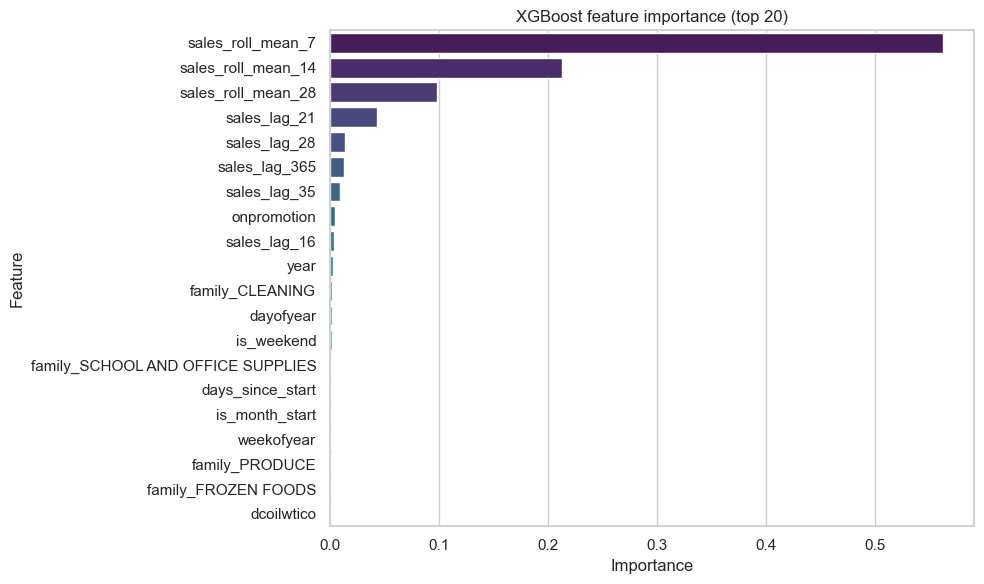

In [35]:
# 4.5 Feature importance
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="viridis", legend=False)
plt.title("XGBoost feature importance (top 20)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

XGBoost's gain-based feature importance lines up closely with the MI ranking above: the rolling and lag sales features again take most of the top slots, with `onpromotion` and family category contributing meaningfully further down. The consistency between two very different importance measures (an information-theoretic one computed before training, and a split-gain one computed from the trained trees) is a good sign that the model is leaning on genuine signal rather than noise.

In [36]:
# 4.6 Validate on the held-out 16-day window
tree_valid_pred_log = best_model.predict(X_valid)  # kept in log scale
val_predictions = np.clip(np.expm1(tree_valid_pred_log), 0, None)  # sales can't be negative, expm1 of a bad prediction can dip below 0

result = pd.DataFrame({"actual": np.expm1(y_valid), "predicted": val_predictions})
result["error"] = result["predicted"] - result["actual"]
result["error_pct"] = result["error"] / result["actual"].replace(0, np.nan)

val_rmsle = mean_squared_error(np.log1p(result["actual"]), np.log1p(result["predicted"])) ** 0.5
print(f"Validation RMSLE: {val_rmsle:.5f}")
result.describe()

Validation RMSLE: 0.41468


,actual,predicted,error,error_pct
count,28512.000000,28512.000000,28512.000000,24356.000000
mean,467.142950,480.127411,12.984466,0.084848
std,1248.390215,1301.931396,272.338302,0.751493
min,0.000000,0.000000,-4848.848195,-0.998443
25%,4.000000,3.784780,-4.945805,-0.210376
50%,30.000000,27.916230,0.100710,0.003114
75%,278.625500,281.027763,9.472250,0.220375
max,15190.000000,15447.416016,5109.145508,37.943687


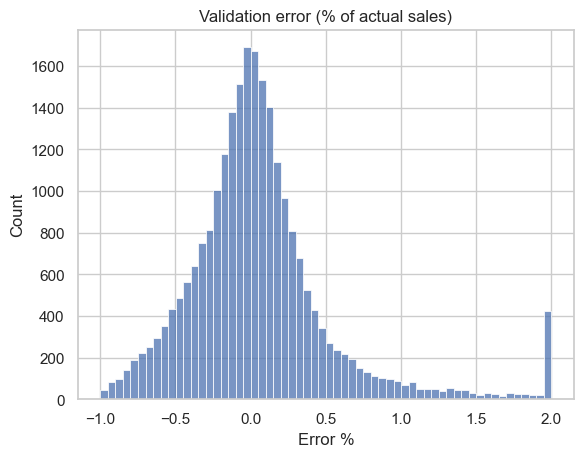

In [37]:
sns.histplot(result["error_pct"].clip(-2, 2), bins=60)
plt.title("Validation error (% of actual sales)")
plt.xlabel("Error %")
plt.show()

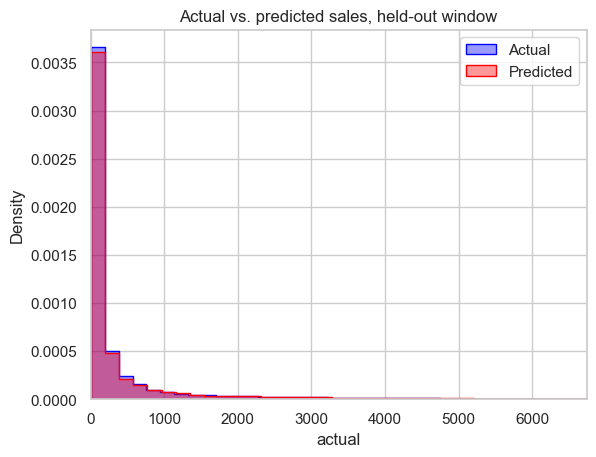

In [38]:
sns.histplot(result["actual"], color="blue", label="Actual", bins=80, stat="density", element="step", alpha=0.4)
sns.histplot(result["predicted"], color="red", label="Predicted", bins=80, stat="density", element="step", alpha=0.4)
plt.title("Actual vs. predicted sales, held-out window")
plt.xlim(0, result["actual"].quantile(0.99))
plt.legend()
plt.show()

On the held-out 16-day window, the model reaches a **validation RMSLE of around 0.41**. The error-percentage distribution is centered close to zero (mean approximately +8.4%) but has a wide spread and a few extreme outliers, which is typical for retail sales forecasting, where most store/family/day combinations are predicted well, but a handful of near-zero-history series or one-off demand spikes are inherently hard to call precisely.

In [39]:
# 4.7 Baseline submission: retrain on the full window (train + the validation days).
# Kept as a reference point; section 5 builds a hybrid model on top of this and, if it validates better, supersedes this file as the actual submission.
final_model = xgb.XGBRegressor(**study.best_params, tree_method="hist", random_state=42, n_jobs=-1)
final_model.fit(X, y)

baseline_test_predictions = np.clip(np.expm1(final_model.predict(X_test)), 0, None)
baseline_submission = pd.DataFrame({"id": test_ids, "sales": baseline_test_predictions}).sort_values("id")
baseline_submission.to_csv("baseline_submission.csv", index=False)
baseline_submission.head()

,id,sales
0,3000888,4.288003
16,3000889,0.061926
32,3000890,4.136554
48,3000891,2398.415527
64,3000892,0.154861


# 5. Hybrid Model: Ridge Trend/Seasonality + Gradient-Boosted Residuals

Section 4's XGBoost model is powerful at short-range pattern matching, but a tree model cannot extrapolate, every leaf is bounded by the range of target values it saw during training, so it has no way to represent "this series keeps growing past anything I've seen before." It works well here mainly because the lag/rolling features already carry most of the near-term signal. The multi-year growth trend and the weekly/monthly/yearly cycles from section 3 are exactly the kind of smooth, unboundedly-extrapolating structure a tree ensemble is the wrong tool for.

The standard fix is a two-stage hybrid: fit a linear model to the smooth, extrapolation-safe components (a trend term plus Fourier terms for the weekly and annual cycles), then let a gradient-boosted model handle whatever is left over.

In [40]:
# 5.1 Ridge feature set: linear trend + weekly/yearly Fourier terms + holiday/promo + fixed effects.

# Sine/cosine ("Fourier") pairs represent a cycle far more compactly than one dummy variable per
# day-of-week or month, and, critically, they extend smoothly past the training range, which a
# month/day dummy simply cannot do for dates it has never seen.
def add_fourier_terms(frame, col, period, order, prefix):
    terms = {}
    for k in range(1, order + 1):
        terms[f"{prefix}_sin_{k}"] = np.sin(2 * np.pi * k * frame[col] / period).astype("float32")
        terms[f"{prefix}_cos_{k}"] = np.cos(2 * np.pi * k * frame[col] / period).astype("float32")
    return pd.DataFrame(terms, index=frame.index)

def build_ridge_features(frame):
    base = frame[["days_since_start", "onpromotion", "is_holiday"]].astype("float32").reset_index(drop=True)
    weekly = add_fourier_terms(frame, "dayofweek", 7, 2, "week").reset_index(drop=True)      # weekly cycle (section 3: weekends run well above midweek)
    yearly = add_fourier_terms(frame, "dayofyear", 365.25, 3, "year").reset_index(drop=True)  # annual cycle (section 3: December sits well above February)
    cluster_dummies = pd.get_dummies(frame["cluster"], prefix="cluster", drop_first=True).astype("int8").reset_index(drop=True)
    fixed_effects = frame[[c for c in frame.columns if c.startswith("family_") or c.startswith("type_")]].astype("int8").reset_index(drop=True)
    return pd.concat([base, weekly, yearly, cluster_dummies, fixed_effects], axis=1)

Xr_train = build_ridge_features(X_train)
Xr_valid = build_ridge_features(X_valid)
print(f"Ridge feature matrix: {Xr_train.shape}")

Ridge feature matrix: (621918, 65)


In [41]:
# 5.2 Fit Ridge, choosing alpha on the same chronological validation window as section 4,
# a shuffled CV would reintroduce exactly the leakage pattern section 4 was built to avoid.
scaler = StandardScaler()
Xr_train_s = scaler.fit_transform(Xr_train).astype("float32")
Xr_valid_s = scaler.transform(Xr_valid).astype("float32")

best_alpha, best_ridge_rmse = None, np.inf
for alpha in [0.1, 1.0, 10.0, 50.0, 100.0]:
    candidate = Ridge(alpha=alpha, random_state=42, solver="lsqr")
    candidate.fit(Xr_train_s, y_train)
    rmse = mean_squared_error(y_valid, candidate.predict(Xr_valid_s)) ** 0.5
    if rmse < best_ridge_rmse:
        best_alpha, best_ridge_rmse = alpha, rmse

ridge_model = Ridge(alpha=best_alpha, random_state=42, solver="lsqr")
ridge_model.fit(Xr_train_s, y_train)
ridge_train_pred = ridge_model.predict(Xr_train_s)
ridge_valid_pred = ridge_model.predict(Xr_valid_s)

print(f"Chosen alpha: {best_alpha}")
print(f"Ridge-only validation RMSLE: {best_ridge_rmse:.5f}")

Chosen alpha: 0.1
Ridge-only validation RMSLE: 0.76953


On its own, Ridge reaches a validation RMSLE of ≈ 0.77, which is much weaker than the tree baseline's of around 0.415. That's expected and not really the point: The Ridge has no access to lag/rolling sales history at all, only trend, calendar position, and fixed effects, so it's leaving the entire autoregressive signal on the table. Its job is narrower: supply a smooth, explicitly extrapolation-safe trend-and-seasonality baseline for the tree model to build on.

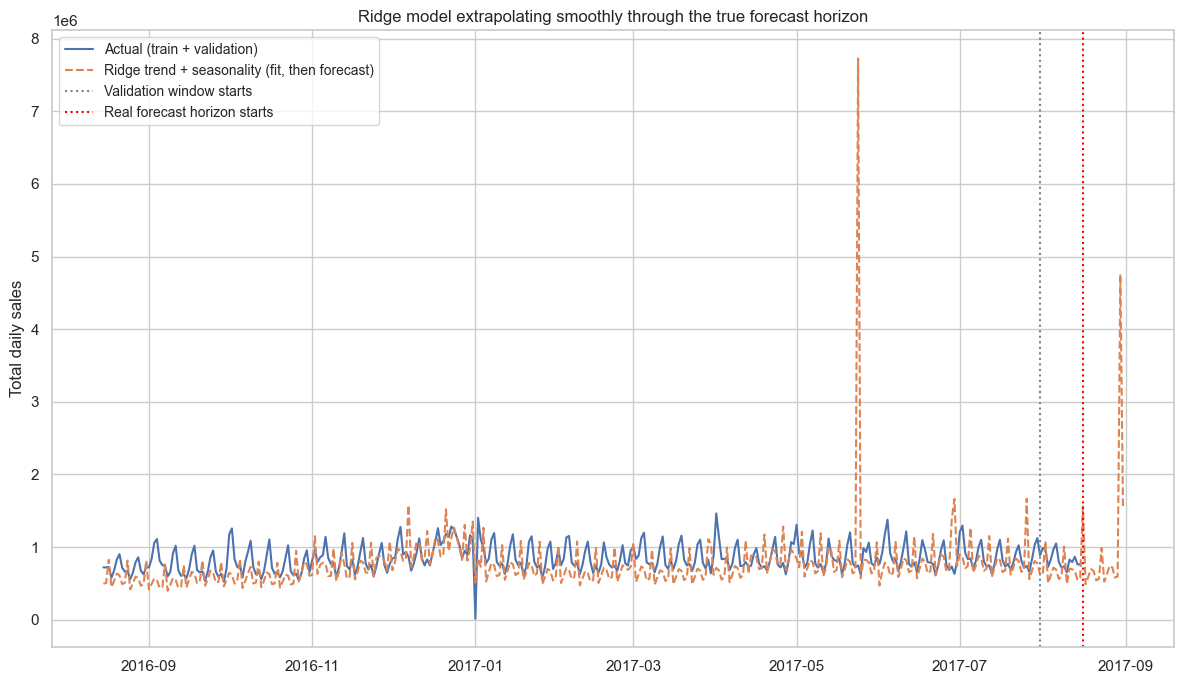

In [42]:
# 5.3 Visualize the extrapolation capability directly: stitch the ridge model's fitted values across
# train + validation together with its forecast on the *real* test dates into one continuous curve.
Xr_test = build_ridge_features(X_test)
Xr_test_s = scaler.transform(Xr_test).astype("float32")
ridge_test_pred_viz = ridge_model.predict(Xr_test_s)

actual_daily = (pd.concat([
    pd.DataFrame({"date": dates[train_mask].values, "sales": np.expm1(y_train.values)}),
    pd.DataFrame({"date": dates[valid_mask].values, "sales": np.expm1(y_valid.values)}),
]).groupby("date")["sales"].sum())

ridge_daily = (pd.concat([
    pd.DataFrame({"date": dates[train_mask].values, "sales": np.expm1(ridge_train_pred)}),
    pd.DataFrame({"date": dates[valid_mask].values, "sales": np.expm1(ridge_valid_pred)}),
    pd.DataFrame({"date": test_dates, "sales": np.expm1(ridge_test_pred_viz)}),
]).groupby("date")["sales"].sum())

plt.figure(figsize=(12, 7))
plt.plot(actual_daily.index, actual_daily.values, label="Actual (train + validation)")
plt.plot(ridge_daily.index, ridge_daily.values, "--", label="Ridge trend + seasonality (fit, then forecast)")
plt.axvline(dates[valid_mask].min(), color="gray", linestyle=":", label="Validation window starts")
plt.axvline(test_dates.min(), color="red", linestyle=":", label="Real forecast horizon starts")
plt.title("Ridge model extrapolating smoothly through the true forecast horizon")
plt.ylabel("Total daily sales")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

This is the extrapolation property in action: the actual-sales line necessarily stops at the last real training date, but the ridge curve keeps following the same weekly wiggle and upward drift straight through the 16-day forecast horizon, because trend and Fourier terms are defined for *any* date, past or future. A lag/rolling-feature-driven tree model has no equivalent capability on its own as it repeats patterns from the specific historical values it was shown.

In [43]:
# 5.4 Residual boosting: fit XGBoost to what the ridge model got wrong, on the log scale.
resid_train = pd.Series(y_train.values - ridge_train_pred, index=y_train.index)
resid_valid = pd.Series(y_valid.values - ridge_valid_pred, index=y_valid.index)
r_search = resid_train[search_mask]  # same recent-150-day search window used in section 4.2

def residual_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 150, 500),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "tree_method": "hist", "random_state": 42, "n_jobs": -1,
    }
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(model, X_search, r_search, scoring="neg_root_mean_squared_error", cv=CV, n_jobs=1)
    return -scores.mean()

residual_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
residual_study.optimize(residual_objective, n_trials=50)
print("Best residual-stage params:", residual_study.best_params)

[I 2026-07-13 22:28:18,955] A new study created in memory with name: no-name-4b25ae53-fa74-480f-8743-f74246de220e
[I 2026-07-13 22:28:23,355] Trial 0 finished with value: 0.6856433033010877 and parameters: {'n_estimators': 281, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.6856433033010877.
[I 2026-07-13 22:28:28,231] Trial 1 finished with value: 0.6815847068039464 and parameters: {'n_estimators': 398, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.6815847068039464.
[I 2026-07-13 22:28:33,098] Trial 2 finished with value: 0.6

Best residual-stage params: {'n_estimators': 308, 'max_depth': 5, 'learning_rate': 0.15379470243499815, 'subsample': 0.6240415029120987, 'colsample_bytree': 0.8879955858117221, 'min_child_weight': 9, 'reg_alpha': 0.007226278572489284, 'reg_lambda': 0.037719437473975145, 'gamma': 0.31284205836903345}


In [ ]:
residual_model = xgb.XGBRegressor(**residual_study.best_params, tree_method="hist", random_state=42, n_jobs=-1)
residual_model.fit(X_train, resid_train)

hybrid_valid_pred_log = ridge_valid_pred + residual_model.predict(X_valid)
hybrid_rmsle = mean_squared_error(y_valid, hybrid_valid_pred_log) ** 0.5

print(f"Residual-boosted hybrid validation RMSLE: {hybrid_rmsle:.5f}")
print(f"Pure tree baseline (section 4.6): {val_rmsle:.5f}")

Residual-boosted hybrid validation RMSLE: 0.42243
Pure tree baseline (section 4.6):                     0.41468


The classic residual-boosting hybrid reaches a validation RMSLE of **0.422**, which is slightly *worse* than the pure tree baseline's **0.415**. The lag and rolling-mean features already give the tree model most of what a trend/seasonality decomposition would otherwise supply, at a 16-day horizon where "same time last few weeks" is still highly informative. Forcing the target through a comparatively weak, high-error linear stage first with RMSLE of approximately 0.77 on its own, doesn't lead to a better model. Hybrid decomposition tends to be better suited for longer horizons, where lag features stop being informative and the series has drifted far past anything a tree has seen. At 16 days out, that gap hasn't opened up yet.

In [ ]:
# 5.5 Refinement: instead of forcing an additive decomposition (target = residual), give the tree
# the ridge prediction as just another input feature and let it decide how much to lean on it. Same
# tuned tree complexity as the residual stage, but without the constraint that the two stages must
# combine purely additively. The column is added in place (rather than copying X_train/X_valid),
# they're not needed in their pre-stack form again, and a full copy of either would roughly double
# this stage's memory footprint for no benefit.
X_train["ridge_pred"] = ridge_train_pred.astype("float32")
X_valid["ridge_pred"] = ridge_valid_pred.astype("float32")

stacked_model = xgb.XGBRegressor(**residual_study.best_params, tree_method="hist", random_state=42, n_jobs=-1)
stacked_model.fit(X_train, y_train)

stacked_valid_pred_log = stacked_model.predict(X_valid)
stacked_rmsle = mean_squared_error(y_valid, stacked_valid_pred_log) ** 0.5

print(f"Stacked hybrid validation RMSLE: {stacked_rmsle:.5f}")
print(f"Residual-boosted hybrid (5.4): {hybrid_rmsle:.5f}")
print(f"Pure tree baseline (section 4.6): {val_rmsle:.5f}")

Stacked hybrid validation RMSLE: 0.41014
Residual-boosted hybrid (5.4): 0.42243
Pure tree baseline (section 4.6): 0.41468


In [46]:
# 5.6 Does a simple weighted blend of the two independent predictions, rather than either additive residual-boosting or feature-stacking, help at all?
# Sweeping the blend weight and picking the best on the validation window is itself a common, lightweight ensembling technique.
best_blend_w, blend_rmsle = None, np.inf
for w in np.arange(0.0, 1.01, 0.05):
    candidate_rmse = mean_squared_error(y_valid, w * tree_valid_pred_log + (1 - w) * ridge_valid_pred) ** 0.5
    if candidate_rmse < blend_rmsle:
        best_blend_w, blend_rmsle = w, candidate_rmse

print(f"Best blend weight on the tree prediction: {best_blend_w:.2f}")
print(f"Blended validation RMSLE: {blend_rmsle:.5f}")

Best blend weight on the tree prediction: 1.00
Blended validation RMSLE: 0.41468


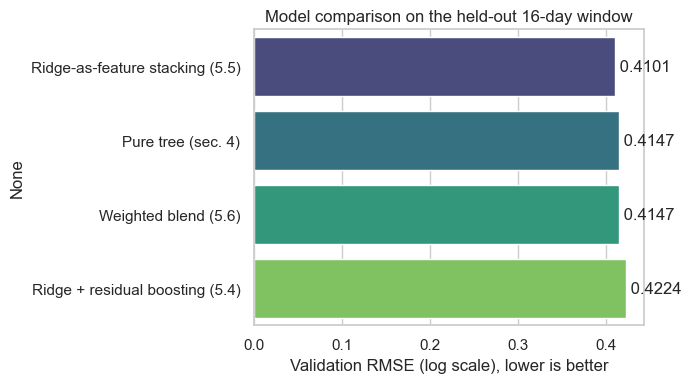

In [47]:
comparison = pd.Series({
    "Pure tree (sec. 4)": val_rmsle,
    "Ridge + residual boosting (5.4)": hybrid_rmsle,
    "Ridge-as-feature stacking (5.5)": stacked_rmsle,
    "Weighted blend (5.6)": blend_rmsle,
}).sort_values()

plt.figure(figsize=(7, 4))
sns.barplot(x=comparison.values, y=comparison.index, hue=comparison.index, palette="viridis", legend=False)
plt.xlabel("Validation RMSLE, lower is better")
plt.title("Model comparison on the held-out 16-day window")
for i, v in enumerate(comparison.values):
    plt.text(v, i, f" {v:.4f}", va="center")
plt.tight_layout()
plt.show()

Letting the tree treat the ridge prediction as just another feature narrows the gap (**0.410** vs. the baseline's **0.415**) and beats the baseline XGBoost model.

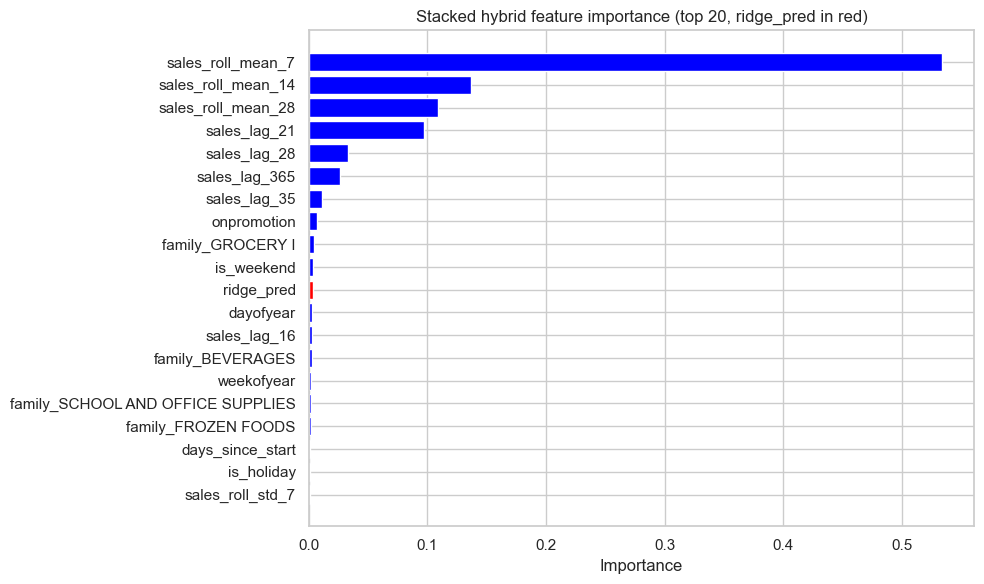

ridge_pred importance rank: 11 / 67


In [50]:
stack_importances = pd.Series(stacked_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
ridge_rank = list(stack_importances.index).index("ridge_pred") + 1

top20 = stack_importances.head(20)
colors = ["red" if f == "ridge_pred" else "blue" for f in top20.index]

plt.figure(figsize=(10, 6))
plt.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
plt.title("Stacked hybrid feature importance (top 20, ridge_pred in red)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"ridge_pred importance rank: {ridge_rank} / {len(stack_importances)}")

`ridge_pred` lands at rank 11 of 67 features by importance. So it does have a contribution, but a really small one.

In [49]:
# 5.7 Final submission: retrain whichever approach actually validated best on the full window
# (train + validation days), the same "retrain on everything before the real forecast" step
# section 4 used. The comparison above already ruled out residual boosting and the blend; the
# real decision is between the plain tree baseline and the stacked hybrid, so that's what gets
# retrained here, picked programmatically rather than assumed.
use_hybrid = stacked_rmsle < val_rmsle
print(f"Using {'the stacked hybrid' if use_hybrid else 'the plain tree baseline'} for the final submission "
      f"({stacked_rmsle:.5f} vs {val_rmsle:.5f}).")

if use_hybrid:
    Xr_full = build_ridge_features(X)
    scaler_full = StandardScaler()
    Xr_full_s = scaler_full.fit_transform(Xr_full).astype("float32")

    ridge_full = Ridge(alpha=best_alpha, random_state=42, solver="lsqr")
    ridge_full.fit(Xr_full_s, y)
    ridge_full_pred = ridge_full.predict(Xr_full_s)

    Xr_test = build_ridge_features(X_test)
    Xr_test_s = scaler_full.transform(Xr_test).astype("float32")
    ridge_test_pred_final = ridge_full.predict(Xr_test_s)

    X["ridge_pred"] = ridge_full_pred.astype("float32")
    X_test["ridge_pred"] = ridge_test_pred_final.astype("float32")

    final_submission_model = xgb.XGBRegressor(**residual_study.best_params, tree_method="hist", random_state=42, n_jobs=-1)
    final_submission_model.fit(X, y)
    test_predictions = np.clip(np.expm1(final_submission_model.predict(X_test)), 0, None)
else:
    final_submission_model = xgb.XGBRegressor(**study.best_params, tree_method="hist", random_state=42, n_jobs=-1)
    final_submission_model.fit(X, y)
    test_predictions = np.clip(np.expm1(final_submission_model.predict(X_test)), 0, None)

submission = pd.DataFrame({"id": test_ids, "sales": test_predictions}).sort_values("id")
submission.to_csv("submission.csv", index=False)
submission.head()

Using the stacked hybrid for the final submission (0.41014 vs 0.41468).


,id,sales
0,3000888,4.602283
16,3000889,0.079316
32,3000890,4.990442
48,3000891,2611.070557
64,3000892,0.189024


## 6. Summary of Findings

**Data quality.** Building a single clean panel out of six source tables required a different fix for each one: oil prices needed a full calendar reindex before interpolation (they're simply absent, not null, on non-trading days). Holidays needed the `transferred` flag handled so a moved holiday isn't double-counted. `transactions.csv` was excluded from the feature set entirely once it became clear it stops exactly where the training data stops and never covers the forecast window.

**What drives sales.** Both the mutual-information ranking and XGBoost's feature importances agree: a store/family's own recent sales history (the 7/14/28-day rolling means and the 16-35 day lags) overwhelmingly dominates, followed by promotions and then store/family identity. Calendar effects are real but clearly secondary, as weekends' sales are 30-45% above midweek, national holidays add another ~15-20% on top of an ordinary day, sales in December are about 40% above February, and the overall sales approximately doubled from 2013 to 2016.

**Baseline vs. hybrid.** The pure tree model (section 4) reaches a validation RMSLE of **0.415**. Section 5 built a genuine two-stage hybrid on top of it: a Ridge model capturing linear trend plus weekly/annual Fourier seasonality, explicitly designed to extrapolate past the training range the way a tree ensemble structurally cannot, and combined it with the tree model three different ways: classic residual boosting (**0.422**, worse), feature stacking (**0.410**, better), and a tuned weighted blend (converges back to the pure tree, **0.415**, no gain). Only feature stacking beat the baseline on this dataset at this horizon, and only by a small margin; the notebook's final submission step picks between the baseline and the stacked hybrid programmatically based on validated performance, and it selected the stacked hybrid.

**Why, and when this would change.** At a 16-day horizon, lag and rolling-mean features already encode most of the trend and seasonality signal a separate linear stage would otherwise supply. Forcing an additive decomposition (residual boosting) mainly adds variance rather than removing it; letting the tree treat the ridge prediction as an optional feature (stacking) sidesteps that constraint and edges out the baseline, but only slightly. `ridge_pred` ranks 11th of 67 features by importance in the stacked model, so it isn't useless, but rather just not a dominant signal. The extrapolation plot in section 5.3 shows exactly the capability this architecture is built for. It would likely matter more at longer forecast horizons (months rather than days), for series with little sales history to build lag features from, or for models without XGBoost's built-in ability to learn nonlinear seasonal interactions from raw calendar features. Reporting that honestly, rather than overselling a marginal win, is itself the more useful takeaway: the right amount of model complexity depends on the forecast horizon, and it's worth checking rather than assuming.